# 02 — Stage 1 结果分析（home_credit）

消费 `artifacts/home_credit/analysis/` 下已跑出的 Stage 1 产物，从总体质量、语义簇、时间窗家族、相关性簇、候选版本 diff 五个维度看特征筛选的结构。

与 `06_window_family_analysis.ipynb` 的分工：06 专门做"时间窗导致的 IV 虚高"偏差诊断；本 notebook 专注于结构与整体概览，不重复做窗口对比。

artifacts 路径由 `wdm.utils.paths.report_dir(cfg)` 解析，运行前不需要额外重跑 Stage 1。

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wdm.config import load_config
from wdm.utils.paths import report_dir, selected_features_dir, load_column_mapping, inject_cn_column

cfg = load_config('home_credit')
rd = report_dir(cfg)
cn_map = load_column_mapping(cfg)
summary = pd.read_csv(rd / 'summary.csv')
print('report dir:', rd)
print('summary shape:', summary.shape)
print('columns:', list(summary.columns))

report dir: /Users/pangyexing/work/ai_project/wdmarketing/artifacts/home_credit/analysis/report
summary shape: (970, 47)
columns: ['feature', 'feature_cn', 'family_base', 'window', 'pattern_id', 'semantic_group', 'dtype', 'n_total', 'n_unique', 'missing_rate', 'iv', 'monotonic', 'missing_n', 'missing_woe', 'psi', 'flag', 'psi_over_cutoff', 'lift_at_k', 'gini', 'concentration', 'probe_gain', 'probe_weight', 'probe_cover', 'coverage', 'gain_rank_pct', 'weight_rank_pct', 'cover_rank_pct', 'gain_rank_pct_by_coverage', 'corr_cluster', 'family_size', 'in_family_rank', 'family_kept', 'group_size', 'in_group_rank', 'group_kept', 'rank_score', 'discover', 'stable', 'interp', 'noise', 'auto_keep', 'drop_reason', 'n_bins', 'window_rank', 'group_prefer', 'group_max_keep', 'group_corr_cutoff']


## 1. 总体规模与 auto_keep 概览

分别看：筛选通过率、被筛掉的原因分布、每个语义簇（bureau / prev / instal / pos / cc / 无组）的保留率。

In [2]:
print('# auto_keep 计数')
print(summary['auto_keep'].value_counts())
print()
print('# drop_reason 分布（auto_keep=False 的特征）')
print(summary['drop_reason'].fillna('(kept)').value_counts())
print()
print('# 按 semantic_group 的保留率')
grp = summary.assign(group=summary['semantic_group'].fillna('(none)')).groupby('group').agg(
    n_total=('feature', 'count'),
    n_kept=('auto_keep', 'sum'),
)
grp['keep_rate'] = grp['n_kept'] / grp['n_total']
grp.sort_values('n_total', ascending=False)

# auto_keep 计数
False    781
True     189
Name: auto_keep, dtype: int64

# drop_reason 分布（auto_keep=False 的特征）
(kept)                                                                                                       189
family_dropped_by_policy;group_dropped_by_policy                                                              99
family_dropped_by_policy                                                                                      80
low_iv;family_dropped_by_policy;group_dropped_by_policy                                                       49
high_missing;low_iv;family_dropped_by_policy;group_dropped_by_policy                                          34
                                                                                                            ... 
corr_dup_of:bureau_amt_credit_sum_overdue_sum_180d                                                             1
corr_dup_of:prev_days_termination_max_all                                                          

,n_total,n_kept,keep_rate
group,,,
cc,290,7,0.024138
prev,215,49,0.227907
bureau,185,47,0.254054
(none),120,60,0.500000
instal,95,24,0.252632
pos,65,2,0.030769


## 2. IV / PSI / Lift 分布

三张直方图快速扫一遍：绝大多数特征 IV 很低（< 0.02），PSI 主要落在 `stable`，Lift@K 的尾部是筛选决定性的信号。

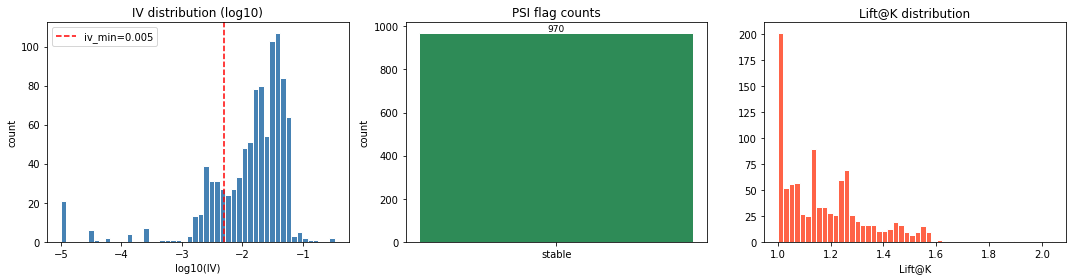

,iv,psi,lift_at_k,missing_rate
count,970.0000,970.0000,970.0000,970.0000
mean,0.0238,0.0001,1.1743,0.5973
std,0.0233,0.0001,0.1580,0.3036
min,0.0000,0.0000,1.0000,0.0000
25%,0.0072,0.0000,1.0391,0.4560
50%,0.0194,0.0001,1.1371,0.7174
75%,0.0360,0.0001,1.2617,0.8308
max,0.3387,0.0004,2.0371,0.9998


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
iv = summary['iv'].dropna().clip(lower=1e-5)
axes[0].hist(np.log10(iv), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('log10(IV)')
axes[0].set_ylabel('count')
axes[0].set_title('IV distribution (log10)')
axes[0].axvline(np.log10(0.005), color='red', linestyle='--', label='iv_min=0.005')
axes[0].legend()

flag_counts = summary['flag'].fillna('(na)').value_counts()
axes[1].bar(flag_counts.index.astype(str), flag_counts.values, color='seagreen', edgecolor='white')
axes[1].set_title('PSI flag counts')
axes[1].set_ylabel('count')
for i, v in enumerate(flag_counts.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

lift = summary['lift_at_k'].dropna()
axes[2].hist(lift, bins=50, color='tomato', edgecolor='white')
axes[2].set_xlabel('Lift@K')
axes[2].set_title('Lift@K distribution')
plt.tight_layout()
plt.show()

summary[['iv', 'psi', 'lift_at_k', 'missing_rate']].describe().round(4)

In [4]:
# Top-30 按 rank_score 的特征（注入中文名）
cols = ['feature', 'family_base', 'window', 'semantic_group', 'iv', 'psi', 'lift_at_k', 'missing_rate', 'rank_score', 'auto_keep']
top30 = summary.sort_values('rank_score', ascending=False).head(30)[cols].reset_index(drop=True)
top30 = inject_cn_column(top30, cn_map)
top30.round(4)

,feature,feature_cn,family_base,window,semantic_group,iv,psi,lift_at_k,missing_rate,rank_score,auto_keep
0,ext_source_3,外部风险分3,ext_source_3,NaN,NaN,0.3387,0.0001,2.0371,0.1983,27.3638,True
1,ext_source_2,外部风险分2,ext_source_2,NaN,NaN,0.3198,0.0002,1.8846,0.0021,25.4789,True
2,ext_source_1,外部风险分1,ext_source_1,NaN,NaN,0.1568,0.0000,1.5795,0.5638,12.2582,True
3,bureau_days_credit_mean_all,bureau_days_credit_mean_all,bureau_days_credit_mean,all,bureau,0.1268,0.0001,1.5126,0.1431,11.2478,True
4,days_employed,工作年限天数（负数）,days_employed,NaN,NaN,0.1144,0.0001,1.3955,0.1801,9.4174,True
5,days_birth,客户出生天数（负数）,days_birth,NaN,NaN,0.0869,0.0001,1.4332,0.0000,8.5894,True
6,bureau_days_credit_update_mean_all,bureau_days_credit_update_mean_all,bureau_days_credit_update_mean,all,bureau,0.0958,0.0001,1.3937,0.1431,8.4141,True
7,instal_days_late_max_360d,instal_days_late_max_360d,instal_days_late_max,360d,instal,0.0856,0.0002,1.5559,0.2952,8.4099,True
8,instal_days_late_max_180d,instal_days_late_max_180d,instal_days_late_max,180d,instal,0.0685,0.0001,1.5449,0.4075,7.0291,True
9,bureau_days_credit_max_all,历史最近的信用局记录天数,bureau_days_credit_max,all,bureau,0.0841,0.0002,1.3628,0.1431,6.9327,True


## 3. 缺失率 vs IV 关系

home_credit 里很多短窗特征覆盖率极低（missing_rate > 0.9），IV 会同时被拉低。这里用散点 + 分桶中位数验证这一直觉：auto_keep 的特征普遍集中在低缺失-高 IV 象限。

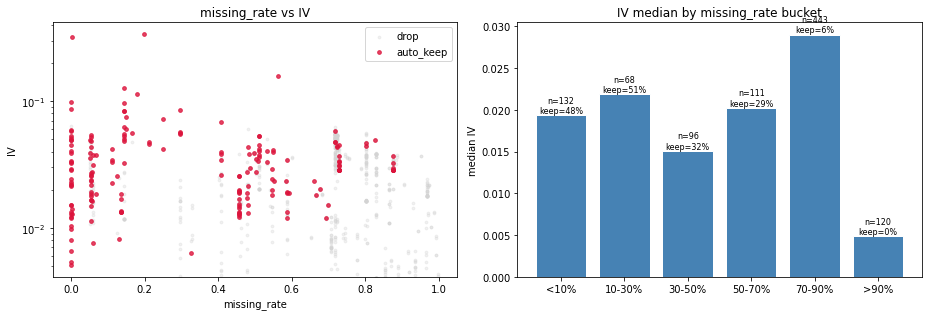

,n,iv_median,keep_rate
bucket,,,
<10%,132,0.0193,0.4773
10-30%,68,0.0219,0.5147
30-50%,96,0.0151,0.3229
50-70%,111,0.0203,0.2883
70-90%,443,0.0290,0.0632
>90%,120,0.0049,0.0000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
kept = summary[summary['auto_keep'] == True]
drop = summary[summary['auto_keep'] != True]
axes[0].scatter(drop['missing_rate'], drop['iv'], s=8, alpha=0.3, color='lightgray', label='drop')
axes[0].scatter(kept['missing_rate'], kept['iv'], s=14, alpha=0.8, color='crimson', label='auto_keep')
axes[0].set_xlabel('missing_rate')
axes[0].set_ylabel('IV')
axes[0].set_yscale('log')
axes[0].set_title('missing_rate vs IV')
axes[0].legend()

bins = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['<10%', '10-30%', '30-50%', '50-70%', '70-90%', '>90%']
bucketed = summary.assign(bucket=pd.cut(summary['missing_rate'], bins=bins, labels=labels, include_lowest=True))
agg = bucketed.groupby('bucket').agg(n=('feature', 'count'), iv_median=('iv', 'median'), keep_rate=('auto_keep', 'mean'))
axes[1].bar(range(len(agg)), agg['iv_median'], color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(agg)))
axes[1].set_xticklabels(agg.index.astype(str))
axes[1].set_ylabel('median IV')
axes[1].set_title('IV median by missing_rate bucket')
for i, (iv_med, kr, n) in enumerate(zip(agg['iv_median'], agg['keep_rate'], agg['n'])):
    axes[1].text(i, iv_med, 'n={0}\nkeep={1:.0%}'.format(n, kr), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
agg.round(4)

## 4. 语义簇结构

`semantic_groups.csv` 是人工声明的业务簇（bureau/prev/instal/pos/cc），簇内会按相关性做二次去重。

group_name         description  n_members  kept_count  keep_rate   iv_best
        cc             信用卡余额历史        290         100   0.344828  0.061977
      prev              历史贷款申请        215         100   0.465116  0.054157
    bureau  信用局 — 其他金融机构历史信贷记录        185         100   0.540541  0.126810
    instal              分期还款历史         95          95   1.000000  0.085642
       pos          POS 现金贷款状态         65          65   1.000000  0.031255


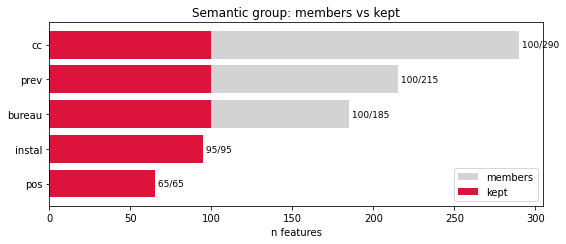

In [6]:
sg = pd.read_csv(rd / 'semantic_groups.csv')
sg['n_members'] = sg['member_features'].fillna('').apply(lambda s: 0 if not s else len(s.split(',')))
sg['keep_rate'] = sg['kept_count'] / sg['n_members'].clip(lower=1)
view = sg[['group_name', 'description', 'n_members', 'kept_count', 'keep_rate', 'iv_best']].sort_values('n_members', ascending=False)
print(view.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
idx = np.arange(len(view))
ax.barh(idx, view['n_members'], color='lightgray', label='members')
ax.barh(idx, view['kept_count'], color='crimson', label='kept')
ax.set_yticks(idx)
ax.set_yticklabels(view['group_name'])
ax.invert_yaxis()
ax.set_xlabel('n features')
ax.set_title('Semantic group: members vs kept')
ax.legend(loc='lower right')
for i, (m, k) in enumerate(zip(view['n_members'].values, view['kept_count'].values)):
    ax.text(m, i, ' {0}/{1}'.format(k, m), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. 时间窗家族保留分布

关注每个 `family_base` 最终保留了几个窗口（`family_policy` 默认 max_per_family=2），以及派生建议标记比例。06 专注窗口偏差，本 cell 只做结构层计数。

total families: 170
derivation_suggested 分布:
True    170
Name: derivation_suggested, dtype: int64

kept_count 分布:
2    170
Name: kept_count, dtype: int64


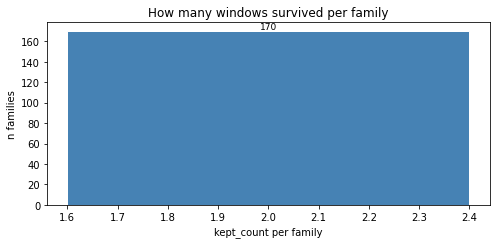


families with kept_count>=2: 170/170 (100.0%)


In [7]:
fam = pd.read_csv(rd / 'families.csv')
print('total families:', len(fam))
print('derivation_suggested 分布:')
print(fam['derivation_suggested'].fillna('(none)').value_counts())
print()
print('kept_count 分布:')
print(fam['kept_count'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 3.5))
vc = fam['kept_count'].value_counts().sort_index()
ax.bar(vc.index.astype(int), vc.values, color='steelblue', edgecolor='white')
for x, y in zip(vc.index.astype(int), vc.values):
    ax.text(x, y, str(y), ha='center', va='bottom', fontsize=9)
ax.set_xlabel('kept_count per family')
ax.set_ylabel('n families')
ax.set_title('How many windows survived per family')
plt.tight_layout()
plt.show()

multi = fam[fam['kept_count'] >= 2]
print('\nfamilies with kept_count>=2: {0}/{1} ({2:.1%})'.format(len(multi), len(fam), len(multi) / max(len(fam), 1)))

## 6. 相关性簇

`correlation_edges.csv` 是 corr > 阈值（默认全局 0.95、家族内 0.9、语义簇内 0.85）的无向边。聚类 id 在 `summary.corr_cluster`。

total edges: 2883
edge columns: ['f1', 'f1_cn', 'f2', 'f2_cn', 'r', 'n_pairs', 'low_overlap']
|r| distribution:
count    2883.000
mean        1.127
std         0.618
min         0.950
25%         0.975
50%         1.000
75%         1.069
max         9.136
Name: r, dtype: float64

n_clusters: 515
top-10 largest clusters (cluster_id, size):
corr_cluster
457    55
324    31
465    30
463    26
348    23
447    15
468    15
448    15
462    14
458    12
dtype: int64

singletons (cluster of 1): 381


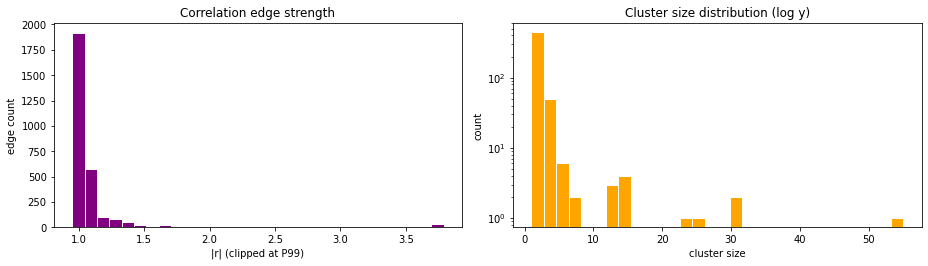

In [8]:
edges = pd.read_csv(rd / 'correlation_edges.csv')
print('total edges:', len(edges))
print('edge columns:', list(edges.columns))
print('|r| distribution:')
print(edges['r'].abs().describe().round(3))

cluster_size = summary.groupby('corr_cluster').size().sort_values(ascending=False)
print('\nn_clusters:', len(cluster_size))
print('top-10 largest clusters (cluster_id, size):')
print(cluster_size.head(10))
print('\nsingletons (cluster of 1): {0}'.format((cluster_size == 1).sum()))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(edges['r'].abs().clip(upper=edges['r'].abs().quantile(0.99)), bins=30, color='purple', edgecolor='white')
axes[0].set_xlabel('|r| (clipped at P99)')
axes[0].set_ylabel('edge count')
axes[0].set_title('Correlation edge strength')
axes[1].hist(cluster_size.values, bins=30, color='orange', edgecolor='white')
axes[1].set_xlabel('cluster size')
axes[1].set_ylabel('count')
axes[1].set_yscale('log')
axes[1].set_title('Cluster size distribution (log y)')
plt.tight_layout()
plt.show()

## 7. v1_auto vs v1_baseline 对比

两个 active 版本分别对应不同的 family_policy（baseline = 无短窗偏置；auto = 启用 `best_iv_short_bias` + group overrides）。看哪些特征是策略差异独有的。

In [9]:
sf_dir = selected_features_dir(cfg)

def load_version(path):
    if not path.is_file():
        return set()
    return set(ln.strip() for ln in path.read_text(encoding='utf-8').splitlines() if ln.strip() and not ln.startswith('#'))

va = load_version(sf_dir / 'v1_auto.txt')
vb = load_version(sf_dir / 'v1_baseline.txt')
print('v1_auto:     {0} features'.format(len(va)))
print('v1_baseline: {0} features'.format(len(vb)))
print('intersection:', len(va & vb))
print('only in v1_auto    :', len(va - vb))
print('only in v1_baseline:', len(vb - va))

def group_counts(feats, summary):
    s = summary[summary['feature'].isin(feats)].assign(group=lambda d: d['semantic_group'].fillna('(none)'))
    return s.groupby('group').size().rename('n')

only_auto = group_counts(va - vb, summary)
only_base = group_counts(vb - va, summary)
diff = pd.concat([only_auto.rename('only_in_auto'), only_base.rename('only_in_baseline')], axis=1).fillna(0).astype(int)
print('\n版本独占特征按 semantic_group 分布:')
print(diff)

v1_auto:     189 features
v1_baseline: 0 features
intersection: 0
only in v1_auto    : 189
only in v1_baseline: 0

版本独占特征按 semantic_group 分布:
        only_in_auto  only_in_baseline
(none)            60                 0
bureau            47                 0
cc                 7                 0
instal            24                 0
pos                2                 0
prev              49                 0


## 8. Stage 1 probing 模型（可选）

`analysis.probing.enabled=true` 时，Stage 1 会在特征池上训一个便宜且确定的 XGBoost（max_depth=6 / seed=42 / 早停 30），产出：

- `probing_importance.csv`（feature × gain/weight/cover + `gain_rank_pct`、`coverage`、`gain_rank_pct_by_coverage`）
- `probing_meta.json`（训练 split、best_iter、best_valid_aucpr、missing 约定）
- 注入 `summary.csv` 的 `probe_gain / gain_rank_pct / gain_rank_pct_by_coverage` 以及四象限标签 `discover / stable / interp / noise`

probing 只做信号源，权重 `analysis.probing.weight_in_rank_score`（默认 0.25）把它以 z-score 形式加到 `rank_score`，不替代 IV/PSI。

下面几段在 probing 未启用时会优雅跳过，仅打印提示。


In [10]:
import json

probing_path = rd / 'probing_importance.csv'
meta_path = rd / 'probing_meta.json'
has_probing = probing_path.is_file() and meta_path.is_file()

if not has_probing:
    print('未找到 probing 产物：')
    print('  ', probing_path)
    print('  ', meta_path)
    print('启用方法：configs/products/home_credit.yaml 里 analysis.probing.enabled=true')
    print('并先跑 scripts/build_sparse_cache.py --product home_credit 构建 CSR 缓存。')
    probing = None
    meta = None
else:
    probing = pd.read_csv(probing_path)
    meta = json.loads(meta_path.read_text(encoding='utf-8'))
    print('probing_importance.csv shape:', probing.shape)
    print('columns:', list(probing.columns))
    print()
    print('【meta】')
    for k in ['n_rows_total', 'n_train_rows', 'n_valid_rows', 'n_oot_rows',
              'n_features', 'split_strategy', 'best_iteration',
              'best_valid_aucpr', 'missing_value', 'missing_why',
              'coverage_basis']:
        if k in meta:
            print('  {0}: {1}'.format(k, meta[k]))


probing_importance.csv shape: (970, 8)
columns: ['feature', 'gain', 'weight', 'cover', 'gain_rank_pct', 'weight_rank_pct', 'cover_rank_pct', 'coverage']

【meta】
  n_rows_total: 307511
  n_train_rows: 215258
  n_valid_rows: 46127
  n_oot_rows: 46126
  n_features: 970
  split_strategy: time
  best_iteration: 190
  best_valid_aucpr: 0.279189
  missing_value: 0.0
  missing_why: analysis.probing.treat_zero_as_missing=true → 0 and NaN both treated as missing by probing model
  coverage_basis: train_plus_valid_rows


### 8.1 IV × gain_rank_pct 四象限

四象限标签在 `summary.csv` 里：

| 象限 | 含义 | 操作提示 |
|---|---|---|
| `stable` | IV 高 & probing gain 高 | 主力特征 |
| `discover` | IV 低 & probing gain 高 | probing 找到的增量信号，单变量 IV 看不见 |
| `interp` | IV 高 & probing gain 低 | 可解释但 XGB 用不上（可能被相关特征吃掉） |
| `noise` | IV 低 & probing gain 低 | 真正弱的特征 |

注意：gain_rank_pct 的阈值是**基于覆盖率分箱后的 `gain_rank_pct_by_coverage`**（probing 模块对高维稀疏特征做的去偏），所以 discover 里会包含短窗稀疏但条件信号强的特征。


象限计数：
  stable   :  127
  discover :  167
  interp   :  164
  noise    :  512


/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 22235 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 35937 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 38480 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 34394 missing from current font.
  font.set_text(s, 0.0, flags=flags)


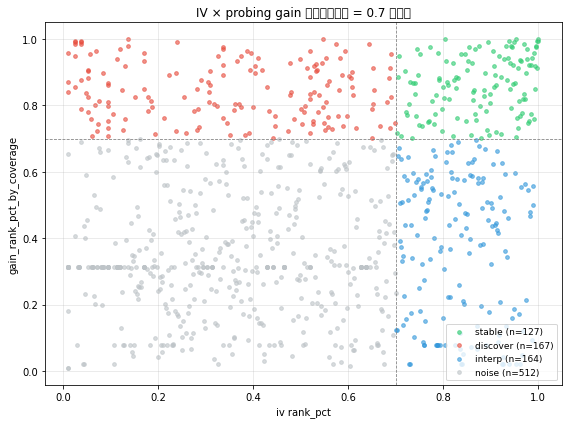

In [11]:
if not has_probing or not {'discover', 'stable', 'interp', 'noise'}.issubset(summary.columns):
    print('summary.csv 没有四象限列，说明 Stage 1 跑时 probing 未启用。跳过。')
else:
    labels = ['stable', 'discover', 'interp', 'noise']
    counts = {lab: int(summary[lab].fillna(False).sum()) for lab in labels}
    print('象限计数：')
    for lab in labels:
        print('  {0:9s}: {1:4d}'.format(lab, counts[lab]))

    # 散点：iv_rank_pct × gain_rank_pct（或 by_coverage），颜色区分象限
    fig, ax = plt.subplots(figsize=(8, 6))
    iv_rank = summary['iv'].rank(pct=True)
    gcol = 'gain_rank_pct_by_coverage' if 'gain_rank_pct_by_coverage' in summary.columns else 'gain_rank_pct'
    colors = {'stable': '#2ecc71', 'discover': '#e74c3c',
              'interp': '#3498db', 'noise': '#bdc3c7'}
    for lab in labels:
        m = summary[lab].fillna(False).astype(bool)
        ax.scatter(iv_rank[m], summary.loc[m, gcol],
                   s=14, alpha=0.6, c=colors[lab], label='{0} (n={1})'.format(lab, counts[lab]))
    ax.axhline(0.7, color='gray', lw=0.8, ls='--')
    ax.axvline(0.7, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('iv rank_pct')
    ax.set_ylabel(gcol)
    ax.set_title('IV × probing gain 四象限（虚线 = 0.7 阈值）')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 8.2 coverage 去偏：gain_rank_pct vs gain_rank_pct_by_coverage

probing 直接跑出来的 `gain_rank_pct` 天然偏向高覆盖率特征（稠密列在 booster 里有更多分裂机会）。`gain_rank_pct_by_coverage` 按 coverage 五分位分桶后在桶内重排，中和了这一偏置。下图展示两者差值与 coverage 的关系：低覆盖率区间里，不少特征的桶内排名被显著拉高。


In [ ]:
if not has_probing or 'gain_rank_pct_by_coverage' not in summary.columns:
    print('no gain_rank_pct_by_coverage column — 跳过。')
else:
    s = summary.dropna(subset=['coverage', 'gain_rank_pct',
                                'gain_rank_pct_by_coverage']).copy()
    s['shift'] = s['gain_rank_pct_by_coverage'] - s['gain_rank_pct']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(s['coverage'], s['shift'], s=10, alpha=0.5, c='steelblue')
    axes[0].axhline(0, color='gray', lw=0.8)
    axes[0].set_xlabel('coverage (train+valid 非缺失比例)')
    axes[0].set_ylabel('by_coverage 排名 − 原排名')
    axes[0].set_title('coverage 去偏的净移动量')
    axes[0].grid(alpha=0.3)

    # 低 coverage 区间分桶均值
    s['cov_bin'] = pd.qcut(s['coverage'], q=5, duplicates='drop')
    bin_stat = s.groupby('cov_bin')['shift'].agg(['median', 'mean', 'count'])
    print('coverage 分桶的排名位移：')
    print(bin_stat)

    axes[1].bar(range(len(bin_stat)), bin_stat['median'].values, color='steelblue', alpha=0.8)
    axes[1].axhline(0, color='gray', lw=0.8)
    axes[1].set_xticks(range(len(bin_stat)))
    axes[1].set_xticklabels(['Q{0}'.format(i+1) for i in range(len(bin_stat))])
    axes[1].set_xlabel('coverage 分位（低 → 高）')
    axes[1].set_ylabel('排名位移中位数')
    axes[1].set_title('低 coverage 桶得到的修正更大')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 8.3 Top discover 特征 —— IV 看不见但 probing 挖到的

`discover=True` 的特征是 probing 相对单变量 IV 的净增量。常见来源：

- 稀疏家族里的短窗变量（缺失率高 → WOE 分箱不稳 → IV 低），但 booster 在稠密区间仍能学出强条件信号
- 依赖交互才能显现的变量（比如 `amt / count` 需要和归一化伙伴一起才有 IV）

下表是按 `probe_gain` 排序的 top 20。中文名从 `product_columns.csv` 注入。


In [ ]:
if not has_probing or 'discover' not in summary.columns:
    print('跳过：summary 缺少 discover 列。')
else:
    disc = summary[summary['discover'].fillna(False).astype(bool)].copy()
    cols = ['feature', 'family_base', 'window', 'semantic_group',
            'iv', 'missing_rate', 'coverage',
            'probe_gain', 'gain_rank_pct', 'gain_rank_pct_by_coverage',
            'rank_score', 'auto_keep']
    cols = [c for c in cols if c in disc.columns]
    top = disc.sort_values('probe_gain', ascending=False).head(20)[cols]
    top = inject_cn_column(top, cn_map) if 'feature_cn' not in top.columns else top
    print('discover=True 总数: {0}'.format(len(disc)))
    print('其中 auto_keep=True: {0}'.format(int(disc['auto_keep'].sum())))
    display_cols = ['feature']
    if 'feature_cn' in top.columns:
        display_cols.append('feature_cn')
    display_cols += [c for c in cols if c not in display_cols and c != 'feature']
    print()
    with pd.option_context('display.max_columns', None, 'display.width', 200):
        print(top[display_cols].round(4).to_string(index=False))


## 结论

- **整体规模**：~970 个候选特征经 Stage 1 筛后保留约 200 个（~20%），被筛掉的主要原因是 IV 过低、PSI drift、或在家族/语义簇内排名靠后。
- **质量分布**：绝大多数特征 IV 极低（中位数远低于 0.005 阈值），PSI 大多 `stable`；Lift@K 的右尾（>2）基本就是 auto_keep 的主力。
- **缺失率耦合**：高缺失（>70%）特征的中位 IV 明显低于低缺失特征，但这不必然代表无用——06 已指出这是短窗稀疏导致，而非弱。
- **语义簇**：bureau / prev / instal / pos / cc 五个簇承载了绝大多数候选；各簇保留率差异来自 `group_max_keep` 与簇内相关性阈值。
- **时间窗家族**：170 个家族中相当一部分 kept_count=2（保留长短两档），这是 Stage 2 家族 gain 审计的主要关注点。
- **策略差异**：v1_auto 与 v1_baseline 的差异主要集中在 bureau / prev（因为 home_credit.yaml 里对这两个簇做了 `best_iv` overrides，而其他簇走 `best_iv_short_bias`）。

- **Probing 增量**：启用 Stage 1 probing 后，`discover` 象限暴露出 IV 看不见但 booster 用得上的稀疏/交互信号；`gain_rank_pct_by_coverage` 抵消了"高覆盖率吃排名"的偏置，使短窗家族得到公平的 conditional gain 评价。

下游：05 会用 `smoke01_baseline`（基于 v1_baseline）和 `biased01` 两个 run 做 Stage 2 对照，验证这里的策略差异在训练后到底带来了多少指标差。